In [25]:
#File: fits.ipynb
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [39]:
path = ["../../course_assignments/homework10/M13_0001.fits", 
        "../../course_assignments/homework10/M13_0002.fits", 
        "../../course_assignments/homework10/M13_0003.fits",
        "../../course_assignments/homework10/M13_0004.fits",
        "../../course_assignments/homework10/M13_0005.fits"]

data_tot = []
header_tot = []
for i in path:
    with fits.open(i) as hdul:
        header = hdul[0].header
        data = hdul[0].data
    data_tot.append(data)
    header_tot.append(header)

print(data_tot[0].min())

0


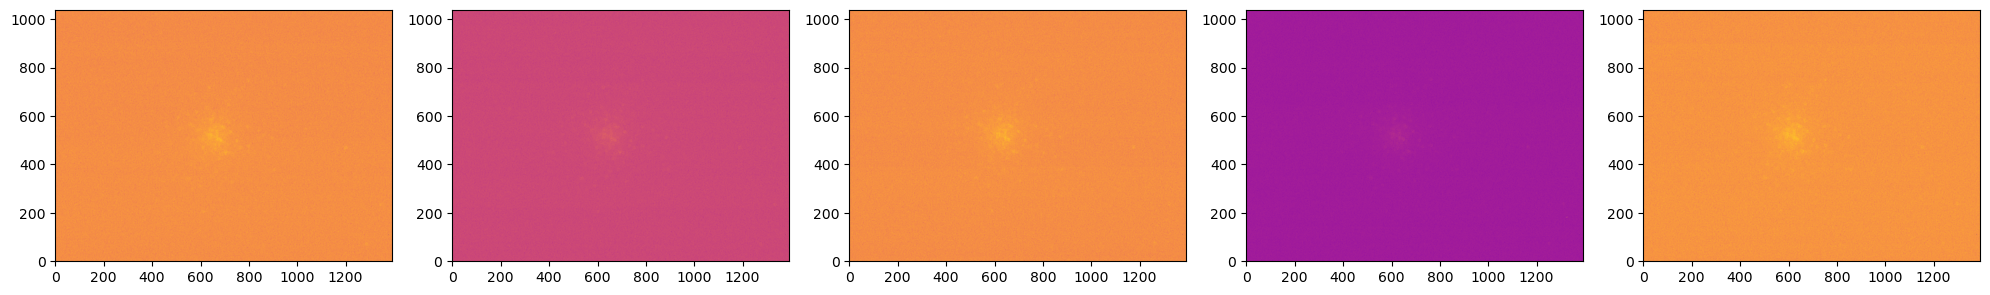

In [34]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i in range(len(axs)):
    axs[i].imshow(data_tot[i], cmap = 'plasma', origin = 'lower')


plt.tight_layout()
plt.show()


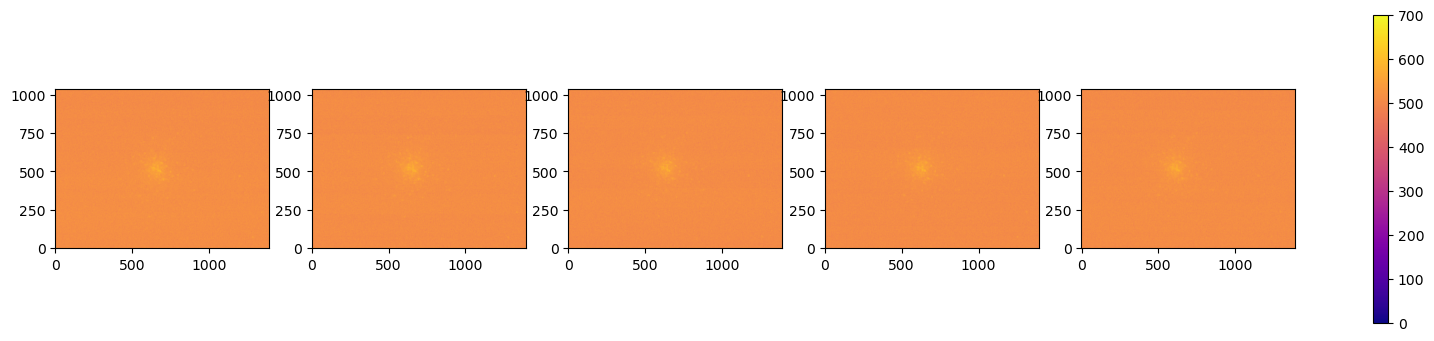

In [52]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

# Save the last imshow object
for i in range(len(axs)):
    im = axs[i].imshow(data_tot[i], cmap='plasma', origin='lower', vmin=0, vmax=701)

# Pass the imshow object to colorbar
plt.colorbar(im, ax=axs)

plt.show()

510.4706668600796
509.7460150033157
508.0498729000884
507.90583554376656
508.7919920148099


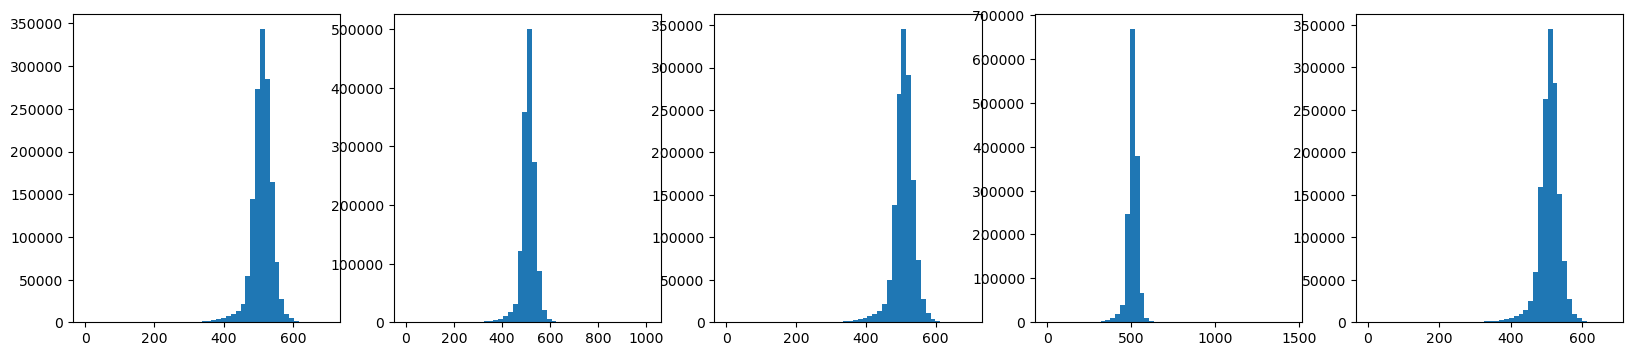

In [59]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i in range(len(data_tot)):
    axs[i].hist(data_tot[i].ravel(), bins=50)
    print(np.mean(data_tot[i]))

plt.show()

1. the x axis is the pixel value while the y axis is the amount of times it shows up
2. the bins are the intervals that the histogram is plotted on
3. most of the data is around a pixel intensity of 500
4. the data is quite tight inside ~1 SD
5. each image has a mean at roughly 510

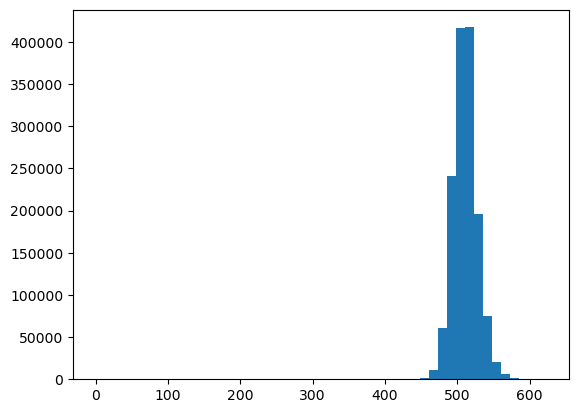

In [61]:
combined_image = np.median(data_tot, axis=0)

plt.hist(combined_image.ravel(), bins=50)
plt.show()

# vmin = 450
# vmax = 550

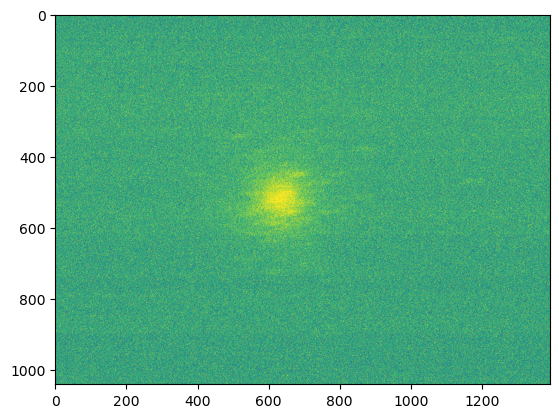

In [64]:
plt.imshow(combined_image, vmin = 450, vmax = 550)
# This image looks lsightly clearer than all of the ones before

In [65]:
fits.writeto("combined.fits", combined_image, overwrite=True)